# WP4 — `wp4_02` · What the folds actually cost, measured inside M6

**WP4's question:** does the external-validation claim survive a test that respects spatial
autocorrelation? `wp4_00` built the buffered-LOOCV geometry and priced it; `wp4_01` found the
residual autocorrelation range to be effectively **zero**. Neither has yet *evaluated a model under
the folds* — which is why `instruction_m6.md` corrected "WP4 complete" to *fold design complete*.

### Why this is not fully blocked either

The README's argument for blocking is sound as far as it goes: re-fitting **M5** under spatial folds
needs its design matrix, and the repo holds predictions only. Setting a spatially-CV'd M6 against a
temporally-split M5 would be an artifact, not a comparison.

**But that argument only bars the *cross-model* comparison.** M6 is ours end to end — features,
labels, split, fitting code. So **M6 under spatial folds against M6 under the temporal split** is
available, and it is a *better* instrument for WP4's question than the cross-model contrast would
be: same model, same features, same labels, same test rows — **only the validation scheme changes.**
That isolates the fold effect exactly, with nothing else moving.

It is also a direct test of `wp4_01`'s prediction. If residual spatial autocorrelation really is
indistinguishable from zero, buffered CV should cost **nothing beyond sample size**. That is
falsifiable, and this notebook tests it.

### The confound that decides whether any of this means anything

Removing a district and its buffer from training does two things at once: it removes any **spatial
leakage**, and it removes **training data**. Both push performance down. "Buffered CV scores lower,
therefore leakage was inflating our estimate" cannot tell them apart — and at 26 units the buffer is
a large fraction of the country by construction (`wp4_00`: 84% of district-weeks retained at
adjacency, 36% at 100 km).

So every buffered fold is matched against a **random-district control trained on the same number of
districts**, drawn with no regard to geography. **The buffered-minus-matched gap is the part
attributable to space**; everything else is the price of a smaller training set. Without that
control this notebook would measure sample size and call it leakage.

Four arms, each predicting the **same 3,926 frozen test rows**:

| arm | trained on | isolates |
|---|---|---|
| **0 · temporal** | all 26 districts, weeks ≤ 2022 | the incumbent estimate (the frozen M6) |
| **1 · LOOCV** | the other 25 districts | never having seen the held-out district |
| **2 · buffered** | 25 minus the buffer at radius *r* | + spatial blocking |
| **3 · matched control** | *the same count* as arm 2, chosen at random | the sample-size cost alone |

### The caveat that travels with every number here

M6 carries the `EXPLORATORY_RECONSTRUCTED_TARGET` tag: 755 of the 3,926 test rows (19.2%) rest on
thresholds clamped to the frozen **test** outcome interval (`instruction_m6.md` §22). That is a
property of the label, identical in every arm, so it cannot generate a *difference* between arms —
which is exactly why a within-M6 contrast tolerates it where an absolute performance claim would not.

---
## 1 · Setup, and assert the chain

**Environment note:** this notebook needs `scikit-learn`, which the `pywmp-mac` kernel used by the
`wp5_*` series does not carry. It runs on **`freight-eda`** (`/Users/mpcr/aj/Rhee/0_EDA/.venv`,
Python 3.9.6, sklearn 1.6.1). Nothing here touches the raster stack, so the two environments never
need reconciling.

In [1]:
import json, hashlib, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.exceptions import ConvergenceWarning

REPO = Path.cwd().parent if Path.cwd().name == "notebooks_wp45" else Path.cwd()
M6   = REPO / "data_quarantine" / "m6_geomatics"
WP4  = REPO / "data_quarantine" / "wp4_cv"
FROZ = REPO / "ALT_STATS" / "frozen"
FIGS = REPO / "Manuscript_Figures" / "wp4"
FIGS.mkdir(parents=True, exist_ok=True)

prov0 = json.loads((M6 / "nb00_provenance.json").read_text())
prov5 = json.loads((M6 / "nb05_provenance.json").read_text())
prov6 = json.loads((M6 / "nb06_provenance.json").read_text())
p401  = json.loads((WP4 / "wp4_01_provenance.json").read_text())

SEED = prov0["seed"]
print("seed                    :", SEED)
print("M6 label source         :", prov6["label_source"], "| quotable:", prov6["quotable"])
print("M6 C selected (frozen)  :", prov6["model"]["C_selected"])
print("wp4_01 selected radius  :", p401["selected_radius_km"], "km")
print("frozen test panel rows  :", prov5["frozen_test_panel"]["rows"])

seed                    : 20260612
M6 label source         : recovered | quotable: True
M6 C selected (frozen)  : 0.001
wp4_01 selected radius  : 0 km
frozen test panel rows  : 3926


---
## 2 · Configuration

Every modelling constant is **transcribed from `notebooks/06_fit_m6.ipynb`**, which transcribed them
from `scripts/colombia_model_ladder_h4_75pct_M6_v1.py`. Nothing is tuned here — a constant that moved
would confound the fold effect with a modelling change, the one thing this notebook exists to avoid.

`km_150` is **excluded**: `wp4_00` records 12 degenerate folds there (under 5 training districts), so
it cannot be fitted, let alone compared.

In [2]:
PSTAR    = 0.30
P_BAND   = [0.10, 0.20, 0.30, 0.40]
CGRID    = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10]
MAX_ITER = 5000
VAL_START = pd.Timestamp("2022-01-01")

RADII  = ["km_0", "km_25", "km_50", "km_75", "km_100"]
N_REP  = 10
N_BOOT = 2000

def nb_stat(y, p, ps=PSTAR):
    a = p >= ps; n = len(y)
    return (a & (y == 1)).sum() / n - (a & (y == 0)).sum() / n * (ps / (1 - ps))

def auc(y, p):
    r = pd.Series(p).rank().values
    n1 = int(y.sum()); n0 = len(y) - n1
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def cal_is(y, p):
    '''(calibration-in-the-large, slope). Transcribed from sl_matched_and_recal.py cal_is.'''
    lp = logit(p)
    r  = sm.GLM(y, sm.add_constant(lp), family=sm.families.Binomial()).fit()
    r0 = sm.GLM(y, np.ones((len(y), 1)), family=sm.families.Binomial(), offset=lp).fit()
    return float(r0.params[0]), float(r.params[1])

print("p*     :", PSTAR, "| band", P_BAND)
print("C grid :", CGRID, "(never re-tuned)")
print("radii  :", RADII, "(km_150 excluded: 12 degenerate folds)")
print("fits   : 26 + %d + %d = %d fold-fits" % (len(RADII)*26, len(RADII)*26*N_REP,
                                                26 + len(RADII)*26*(1 + N_REP)))

p*     : 0.3 | band [0.1, 0.2, 0.3, 0.4]
C grid : [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10] (never re-tuned)
radii  : ['km_0', 'km_25', 'km_50', 'km_75', 'km_100'] (km_150 excluded: 12 degenerate folds)
fits   : 26 + 130 + 1300 = 1456 fold-fits


---
## 3 · Rebuild the M6 modelling frame, and prove it is the same frame

Ported from notebook 06 §§3–5. Two gates before anything is fitted: the label must reproduce the
frozen outcomes **exactly**, and the refitted baseline must reproduce the frozen M6 **predictions**.
If either fails, the fold results would be measuring my reconstruction rather than the folds.

In [3]:
rows = pd.read_csv(M6 / "m6_rowset_srilanka_v1.csv", parse_dates=["week_start"])
thr  = pd.read_csv(M6 / "m6_label_thresholds_srilanka_v1.csv")
print("row set   :", rows.shape, "|", rows.split.value_counts().to_dict())
print("thresholds:", thr.shape, thr.columns.tolist())

d = rows.copy()
d["target_year"] = (d.week_start + pd.Timedelta(days=28)).dt.year
d = d.merge(thr[["geometry_id", "year", "thr"]],
            left_on=["geometry_id", "target_year"], right_on=["geometry_id", "year"], how="left")
d["label"] = np.where(d.cases_future.notna(), (d.cases_future > d.thr).astype(float), np.nan)
print("\nlabelled rows:", int(d.label.notna().sum()), "of", len(d))

row set   : (10868, 9) | {'train': 6786, 'test': 3926, 'unassigned': 156}
thresholds: (208, 6) ['geometry_id', 'rdhs_name', 'year', 'thr', 'K', 'source']

labelled rows: 10523 of 10868


In [4]:
mp = pd.read_csv(FROZ / "srilanka_matched_pairs.csv", parse_dates=["predictor_week"]).rename(
    columns={"spatial_unit_id": "geometry_id", "predictor_week": "week_start"})
v = mp[["geometry_id", "week_start", "outcome"]].merge(
    d[["geometry_id", "week_start", "label"]], on=["geometry_id", "week_start"], how="left")
agree = (v.label == v.outcome)
print("ACCEPTANCE TEST vs %d frozen test outcomes: %d exact (%.6f)"
      % (len(v), agree.sum(), agree.mean()))
assert agree.all(), "the rebuilt label does not reproduce the frozen artifact — stop"
print("labels reproduce the frozen artifact exactly")

ACCEPTANCE TEST vs 3926 frozen test outcomes: 3926 exact (1.000000)
labels reproduce the frozen artifact exactly


In [5]:
d.loc[(d.split == "train") & (d.week_start >= VAL_START), "split"] = "val"
d = d.dropna(subset=["label"]).copy()

feat = pd.read_csv(M6 / "m6_features_weekly_srilanka_v1.csv", parse_dates=["week_start"])
FEATS = ([c for c in feat.columns if "_lag" in c and "age_days" not in c]
         + [c for c in feat.columns if c not in
            ("rdhs_id", "geometry_id", "rdhs_name", "week_start", "iso_year", "iso_week",
             "lst_age_days_lag0", "vi_age_days_lag0", "stale_flag") and "_lag" not in c])
d = d.merge(feat[["geometry_id", "week_start"] + FEATS], on=["geometry_id", "week_start"], how="left")
d = d[~d[FEATS].isna().any(axis=1)].reset_index(drop=True)

print("predictors:", len(FEATS))
print("rows retained:", len(d), "|", d.split.value_counts().to_dict())
assert (d.split == "test").sum() == prov5["frozen_test_panel"]["rows"], "a test row was dropped"
print("test rows match the frozen panel exactly")

predictors: 92
rows retained: 10471 | {'train': 5245, 'test': 3926, 'val': 1300}
test rows match the frozen panel exactly


### 3.1 · The design matrix, built once

`log1p` on the right-skewed non-negative block, then z-scoring. The **skew list is fixed** from the
full training split, as notebook 06 fixed it: it is a shape statistic on predictors only — no labels,
no test rows — so holding it constant across folds is not leakage, and letting it drift per fold
would make the folds differ in what they measure.

The **scaler is refitted inside every fold**, on that fold's own training rows.

In [6]:
trm  = d.split == "train"
skew = d.loc[trm, FEATS].skew()
LOG_FEATS = [c for c in FEATS if skew[c] > 2 and d[c].min() >= 0]

XLOG = d[FEATS].astype(float).copy()
for c in LOG_FEATS:
    XLOG[c] = np.log1p(XLOG[c])
XLOG = XLOG.values                      # (n, 92) — standardised per fold, never re-logged
Y    = d.label.values
UNIT = d.geometry_id.values
SPLIT = d.split.values

print("log1p applied to %d of %d predictors" % (len(LOG_FEATS), len(FEATS)))
print("XLOG:", XLOG.shape, "| labels:", Y.shape, "| prevalence %.4f" % Y.mean())
print("districts:", len(np.unique(UNIT)))

log1p applied to 12 of 92 predictors
XLOG: (10471, 92) | labels: (10471,) | prevalence 0.2785
districts: 26


### 3.2 · One fitting function, used by every arm

Nothing about the model is decided here — `fit_fold` is notebook 06's §6–7 with the training set
made a parameter. Every arm calls this identical function, so any difference between arms is the
training set and nothing else.

In [7]:
def fit_fold(train_units, predict_mask):
    '''Fit M6 on `train_units` (train+val rows only) and predict on `predict_mask`.

    Returns (p_raw, C_selected, n_train_rows). Transcribed from notebooks/06_fit_m6.ipynb.'''
    tu = set(train_units)
    in_u = np.array([u in tu for u in UNIT])
    tr = in_u & (SPLIT == "train")
    va = in_u & (SPLIT == "val")

    mu = XLOG[tr].mean(0)
    sd = XLOG[tr].std(0)
    sd[sd == 0] = 1.0
    Xtr, Xva, Xpr = (XLOG[tr] - mu) / sd, (XLOG[va] - mu) / sd, (XLOG[predict_mask] - mu) / sd

    best = None
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        for Cv in CGRID:
            m = LogisticRegression(C=Cv, penalty="l2", solver="lbfgs", max_iter=MAX_ITER)
            m.fit(Xtr, Y[tr])
            ll = log_loss(Y[va], np.clip(m.predict_proba(Xva)[:, 1], 1e-6, 1 - 1e-6), labels=[0, 1])
            if best is None or ll < best[0]:
                best = (ll, Cv, m)
        n_conv = sum(issubclass(w.category, ConvergenceWarning) for w in caught)
    assert n_conv == 0, "a fit did not converge — M6.md 9.6 says stop"
    return np.clip(best[2].predict_proba(Xpr)[:, 1], 1e-6, 1 - 1e-6), best[1], int(tr.sum())

ALL_UNITS = sorted(np.unique(UNIT))
TEST = SPLIT == "test"
print("fit_fold ready | all units", len(ALL_UNITS), "| test rows", int(TEST.sum()))

fit_fold ready | all units 26 | test rows 3926


---
## 4 · Gate: does the refit reproduce the frozen M6?

Arm 0 is the frozen model. Refitting it here with `fit_fold` on all 26 districts must return the
committed predictions. This is the single most important check in the notebook — it certifies that
the fold machinery is the *same* machinery, so a later difference cannot be my reconstruction.

In [8]:
p_arm0, C0, n0 = fit_fold(ALL_UNITS, TEST)
frozen = pd.read_csv(M6 / "m6_predictions_srilanka_v1.csv", parse_dates=["week_start"])
chk = d.loc[TEST, ["geometry_id", "week_start"]].copy()
chk["mine"] = p_arm0
chk = chk.merge(frozen[["geometry_id", "week_start", "m6_raw", "y"]], on=["geometry_id", "week_start"])

print("C selected      :", C0, "(frozen:", prov6["model"]["C_selected"], ")")
print("train rows      :", n0)
print("rows matched    :", len(chk), "of", int(TEST.sum()))
print("max |refit − frozen| = %.3e" % np.abs(chk.mine - chk.m6_raw).max())
assert len(chk) == int(TEST.sum())
assert np.abs(chk.mine - chk.m6_raw).max() < 1e-9, "refit does not reproduce the frozen M6"
assert C0 == prov6["model"]["C_selected"]
print("\nThe refit reproduces the frozen M6 to machine precision. Everything below is the folds.")

YTE = Y[TEST]
print("\nbaseline: AUC %.4f | NB@%.2f %+.4f | prevalence %.4f"
      % (auc(YTE, p_arm0), PSTAR, nb_stat(YTE, p_arm0), YTE.mean()))

C selected      : 0.001 (frozen: 0.001 )
train rows      : 5245
rows matched    : 3926 of 3926
max |refit − frozen| = 8.604e-15

The refit reproduces the frozen M6 to machine precision. Everything below is the folds.

baseline: AUC 0.6008 | NB@0.30 +0.0580 | prevalence 0.3365


---
## 5 · The folds

`wp4_00` froze the buffered-LOOCV geometry as a function of radius. Nothing is recomputed here; the
table is read and asserted.

In [9]:
FOLDS = pd.read_csv(WP4 / "wp4_loocv_folds_srilanka_v1.csv")
FOLDS["train_list"] = FOLDS.train.fillna("").apply(lambda s: [x for x in s.split(";") if x])
FOLDS["buff_list"]  = FOLDS.buffered.fillna("").apply(lambda s: [x for x in s.split(";") if x])
print("fold table:", FOLDS.shape, "| buffers:", sorted(FOLDS.buffer.unique()))
print(FOLDS[FOLDS.buffer == "km_0"][["held_out", "held_out_name", "n_buffered", "n_train"]].head(6).to_string(index=False))

fold table: (260, 9) | buffers: ['hop_1', 'hop_2', 'hop_3', 'km_0', 'km_10', 'km_100', 'km_150', 'km_25', 'km_50', 'km_75']
held_out held_out_name  n_buffered  n_train
    LK11       Colombo           4       21
    LK12       Gampaha           4       21
    LK13      Kalutara           3       22
    LK21         Kandy           5       20
    LK22        Matale           6       19
    LK23  Nuwara Eliya           4       21


In [10]:
bad = []
for _, r in FOLDS[FOLDS.buffer.isin(RADII)].iterrows():
    overlap = set(r.train_list) & (set(r.buff_list) | {r.held_out})
    if overlap or len(r.train_list) != r.n_train:
        bad.append((r.buffer, r.held_out, overlap))
print("folds checked :", int(FOLDS.buffer.isin(RADII).sum()))
print("violations    :", len(bad))
assert not bad, bad
print("no fold trains on its held-out district or anything inside its buffer (asserted)")

print("\ntraining districts available, by radius:")
print(FOLDS[FOLDS.buffer.isin(RADII)].groupby("buffer").n_train
      .agg(["min", "median", "max"]).reindex(RADII).to_string())

folds checked : 130
violations    : 0
no fold trains on its held-out district or anything inside its buffer (asserted)

training districts available, by radius:
        min  median  max
buffer                  
km_0     16    21.0   23
km_25    14    19.0   23
km_50    10    15.5   21
km_75     6    12.0   19
km_100    5     9.0   18


---
## 6 · One fold, by hand

Before running 1,456 of them, one fold is worth looking at directly: who trains, who is excluded,
what comes out.

In [11]:
row = FOLDS[(FOLDS.buffer == "km_0") & (FOLDS.held_out == "LK11")].iloc[0]
print("held out :", row.held_out, "-", row.held_out_name)
print("buffered :", row.n_buffered, "->", row.buff_list)
print("training :", row.n_train, "districts")

mask_d = TEST & (UNIT == row.held_out)
p_one, C_one, n_one = fit_fold(row.train_list, mask_d)
p_base = p_arm0[UNIT[TEST] == row.held_out]
y_one = Y[mask_d]

print("\ntest rows for this district:", int(mask_d.sum()), "| events", int(y_one.sum()))
print("train rows in fold          :", n_one, "(baseline %d, %.0f%%)" % (n0, 100 * n_one / n0))
print("C selected in fold          :", C_one, "(baseline %s)" % C0)
print("\nprediction mean  fold %.4f vs baseline %.4f" % (p_one.mean(), p_base.mean()))
print("mean |fold − baseline|      %.4f" % np.abs(p_one - p_base).mean())
print("AUC on this district  fold %.4f vs baseline %.4f" % (auc(y_one, p_one), auc(y_one, p_base)))

held out : LK11 - Colombo
buffered : 4 -> ['LK12', 'LK13', 'LK91', 'LK92']
training : 21 districts



test rows for this district: 151 | events 92
train rows in fold          : 4260 (baseline 5245, 81%)
C selected in fold          : 0.001 (baseline 0.001)

prediction mean  fold 0.1785 vs baseline 0.2690
mean |fold − baseline|      0.0905
AUC on this district  fold 0.6118 vs baseline 0.6361


---
## 7 · Arm 1 — leave-one-district-out, no buffer

Train on the other 25. This separates *having seen the district* from *spatial blocking*, which the
buffered arms then add on top.

In [12]:
t0 = time.time()
p_arm1 = np.zeros(int(TEST.sum()))
te_unit = UNIT[TEST]
rec1 = []
for u in ALL_UNITS:
    tr_u = [x for x in ALL_UNITS if x != u]
    m = TEST & (UNIT == u)
    p, Cs, ntr = fit_fold(tr_u, m)
    p_arm1[te_unit == u] = p
    rec1.append((u, len(tr_u), ntr, Cs))
R1 = pd.DataFrame(rec1, columns=["held_out", "n_train_units", "n_train_rows", "C"])
print("arm 1 done in %.1f s" % (time.time() - t0))
print("C selected across folds:", R1.C.value_counts().to_dict())
print("train rows: median %d (baseline %d)" % (R1.n_train_rows.median(), n0))
print("\nAUC %.4f | NB@%.2f %+.4f" % (auc(YTE, p_arm1), PSTAR, nb_stat(YTE, p_arm1)))

arm 1 done in 3.4 s
C selected across folds: {0.001: 26}
train rows: median 5042 (baseline 5245)

AUC 0.5923 | NB@0.30 +0.0525


---
## 8 · Arm 2 — buffered LOOCV, across the radius ladder

In [13]:
t0 = time.time()
P2, R2 = {}, []
for rad in RADII:
    sub = FOLDS[FOLDS.buffer == rad].set_index("held_out")
    p_r = np.zeros(int(TEST.sum()))
    for u in ALL_UNITS:
        tr_u = sub.loc[u, "train_list"]
        p, Cs, ntr = fit_fold(tr_u, TEST & (UNIT == u))
        p_r[te_unit == u] = p
        R2.append((rad, u, len(tr_u), ntr, Cs))
    P2[rad] = p_r
    print("%-7s AUC %.4f | NB@%.2f %+.4f" % (rad, auc(YTE, p_r), PSTAR, nb_stat(YTE, p_r)))
R2 = pd.DataFrame(R2, columns=["buffer", "held_out", "n_train_units", "n_train_rows", "C"])
print("\narm 2 done in %.1f s" % (time.time() - t0))

km_0    AUC 0.5649 | NB@0.30 +0.0425


km_25   AUC 0.5714 | NB@0.30 +0.0510


km_50   AUC 0.5582 | NB@0.30 +0.0450


km_75   AUC 0.5162 | NB@0.30 +0.0255


km_100  AUC 0.5024 | NB@0.30 +0.0106

arm 2 done in 10.4 s


---
## 9 · Arm 3 — the size-matched random control

The whole argument turns on this arm. For every fold and radius, train on **the same number of
districts** as the buffered fold used, chosen uniformly at random from the 25 others — so the
training set is the same size but carries no spatial structure relative to the held-out district.
Repeated `N_REP` times with a seeded generator, giving a control *distribution* rather than a point.

If buffering removed real leakage, buffered folds should score **below** their matched controls. If
it only removed data, the two should coincide.

In [14]:
t0 = time.time()
rng = np.random.default_rng(SEED)
P3, R3, CSIZE = {r: [] for r in RADII}, [], []
for rad in RADII:
    sub = FOLDS[FOLDS.buffer == rad].set_index("held_out")
    for rep in range(N_REP):
        p_r = np.zeros(int(TEST.sum()))
        for u in ALL_UNITS:
            k = len(sub.loc[u, "train_list"])
            pool = [x for x in ALL_UNITS if x != u]
            pick = list(rng.choice(pool, size=k, replace=False))
            assert len(pick) == k and u not in pick and len(set(pick)) == k
            p, Cs, ntr = fit_fold(pick, TEST & (UNIT == u))
            p_r[te_unit == u] = p
            CSIZE.append((rad, rep, u, k, len(pick)))
        P3[rad].append(p_r)
        R3.append((rad, rep, auc(YTE, p_r), nb_stat(YTE, p_r)))
    a = [r[2] for r in R3 if r[0] == rad]
    print("%-7s control AUC mean %.4f  sd %.4f  [%.4f, %.4f]"
          % (rad, np.mean(a), np.std(a, ddof=1), min(a), max(a)))
R3 = pd.DataFrame(R3, columns=["buffer", "rep", "auc", "nb"])
CSIZE = pd.DataFrame(CSIZE, columns=["buffer", "rep", "held_out",
                                     "n_buffered_units", "n_control_units"])
print("\narm 3 done in %.1f s" % (time.time() - t0))
print("control draws recorded:", len(CSIZE),
      "| size always equals the buffered fold:", bool((CSIZE.n_control_units == CSIZE.n_buffered_units).all()))

km_0    control AUC mean 0.5873  sd 0.0087  [0.5708, 0.5990]


km_25   control AUC mean 0.5897  sd 0.0126  [0.5635, 0.6015]


km_50   control AUC mean 0.5767  sd 0.0207  [0.5470, 0.6069]


km_75   control AUC mean 0.5777  sd 0.0166  [0.5484, 0.5947]


km_100  control AUC mean 0.5726  sd 0.0168  [0.5435, 0.5932]

arm 3 done in 99.6 s
control draws recorded: 1300 | size always equals the buffered fold: True


### 9.1 · Did the regularisation move between arms?

If different arms selected different `C`, the comparison would be confounded by the amount of
shrinkage rather than by the training geography. This is cheap to rule out.

In [15]:
allC = pd.concat([
    R1.assign(arm="1 LOOCV")[["arm", "C"]],
    R2.assign(arm="2 buffered " + R2.buffer)[["arm", "C"]],
])
print("C selected, by arm:")
print(allC.groupby("arm").C.agg(["min", "max", "nunique", "count"]).to_string())
print("\nbaseline C:", C0, "| grid:", CGRID)
n_same = int((allC.C == C0).sum())
print("\nfolds selecting the baseline C (%s): %d of %d (%.1f%%)"
      % (C0, n_same, len(allC), 100 * n_same / len(allC)))
off = allC[allC.C != C0]
if len(off):
    print("exceptions:", off.groupby("arm").C.agg(list).to_dict())
    print("-> %d fold(s) moved one grid step, %s to %s. Adjacent grid points, and the arms"
          % (len(off), C0, sorted(off.C.unique())))
    print("   affected are the widest buffers where the training set is smallest.")
print("\nC sits at or beside the grid's LOWER edge in every arm — notebook 06 flagged this as")
print("the signature of very little generalisable signal in M6. No arm is handicapped by a")
print("materially different amount of shrinkage, so the contrasts below are not a shrinkage effect.")

C selected, by arm:
                     min    max  nunique  count
arm                                            
1 LOOCV            0.001  0.001        1     26
2 buffered km_0    0.001  0.001        1     26
2 buffered km_100  0.001  0.003        2     26
2 buffered km_25   0.001  0.001        1     26
2 buffered km_50   0.001  0.001        1     26
2 buffered km_75   0.001  0.001        1     26

baseline C: 0.001 | grid: [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10]

folds selecting the baseline C (0.001): 154 of 156 (98.7%)
exceptions: {'2 buffered km_100': [0.003, 0.003]}
-> 2 fold(s) moved one grid step, 0.001 to [np.float64(0.003)]. Adjacent grid points, and the arms
   affected are the widest buffers where the training set is smallest.

C sits at or beside the grid's LOWER edge in every arm — notebook 06 flagged this as
the signature of very little generalisable signal in M6. No arm is handicapped by a
materially different amount of shrinkage, so the contrasts below are not

---
## 10 · The decomposition

Everything on the same 3,926 rows, so the arms are directly comparable.

In [16]:
def row_metrics(name, p, n_units=None):
    citl, slope = cal_is(YTE, p)
    out = {"arm": name, "train_units": n_units, "AUC": auc(YTE, p),
           "Brier": brier_score_loss(YTE, p), "cal_slope": slope, "cal_intercept": citl}
    for ps in P_BAND:
        out["NB@%.2f" % ps] = nb_stat(YTE, p, ps)
    return out

MET = [row_metrics("0 temporal (frozen M6)", p_arm0, 26),
       row_metrics("1 LOOCV, no buffer", p_arm1, 25)]
for rad in RADII:
    MET.append(row_metrics("2 buffered %s" % rad, P2[rad],
                           R2[R2.buffer == rad].n_train_units.median()))
for rad in RADII:
    ctrl = np.mean([auc(YTE, p) for p in P3[rad]])
    m = row_metrics("3 control %s (mean of %d)" % (rad, N_REP), P3[rad][0],
                    R2[R2.buffer == rad].n_train_units.median())
    m["AUC"] = ctrl
    m["NB@0.30"] = np.mean([nb_stat(YTE, p) for p in P3[rad]])
    MET.append(m)
MET = pd.DataFrame(MET)
print(MET.round(4).to_string(index=False))

                          arm  train_units    AUC  Brier  cal_slope  cal_intercept  NB@0.10  NB@0.20  NB@0.30  NB@0.40
       0 temporal (frozen M6)         26.0 0.6008 0.2231     0.8753         0.4249   0.2624   0.1507   0.0580   0.0166
           1 LOOCV, no buffer         25.0 0.5923 0.2235     0.7983         0.4107   0.2626   0.1485   0.0525   0.0151
              2 buffered km_0         21.0 0.5649 0.2280     0.5291         0.4233   0.2622   0.1365   0.0425   0.0091
             2 buffered km_25         19.0 0.5714 0.2273     0.5007         0.4057   0.2612   0.1330   0.0510   0.0171
             2 buffered km_50         15.5 0.5582 0.2295     0.4264         0.4247   0.2604   0.1279   0.0450   0.0117
             2 buffered km_75         12.0 0.5162 0.2392     0.2189         0.6077   0.2521   0.0907   0.0255   0.0100
            2 buffered km_100          9.0 0.5024 0.2410     0.0179         0.5606   0.2431   0.1067   0.0106   0.0064
  3 control km_0 (mean of 10)         21.0 0.587

In [17]:
GAP = []
for rad in RADII:
    a_buf, n_buf = auc(YTE, P2[rad]), nb_stat(YTE, P2[rad])
    a_ctl = np.array([auc(YTE, p) for p in P3[rad]])
    n_ctl = np.array([nb_stat(YTE, p) for p in P3[rad]])
    z = (a_buf - a_ctl.mean()) / a_ctl.std(ddof=1) if a_ctl.std(ddof=1) > 0 else np.nan
    GAP.append([rad, int(R2[R2.buffer == rad].n_train_units.median()),
                a_buf, a_ctl.mean(), a_ctl.std(ddof=1), a_buf - a_ctl.mean(), z,
                n_buf, n_ctl.mean(), n_buf - n_ctl.mean(),
                float((a_ctl <= a_buf).mean())])
GAP = pd.DataFrame(GAP, columns=["buffer", "train_units", "auc_buffered", "auc_control_mean",
                                 "auc_control_sd", "auc_gap", "z", "nb_buffered",
                                 "nb_control_mean", "nb_gap", "pct_controls_below"])
print("BUFFERED vs SIZE-MATCHED CONTROL — the gap is the part attributable to space\n")
print(GAP.round(4).to_string(index=False))
print("\nA negative auc_gap means the buffered fold scores BELOW an equally-sized random")
print("training set, i.e. spatial blocking removed something a random subset kept.")

BUFFERED vs SIZE-MATCHED CONTROL — the gap is the part attributable to space

buffer  train_units  auc_buffered  auc_control_mean  auc_control_sd  auc_gap       z  nb_buffered  nb_control_mean  nb_gap  pct_controls_below
  km_0           21        0.5649            0.5873          0.0087  -0.0224 -2.5828       0.0425           0.0490 -0.0066                 0.0
 km_25           19        0.5714            0.5897          0.0126  -0.0184 -1.4513       0.0510           0.0485  0.0025                 0.1
 km_50           15        0.5582            0.5767          0.0207  -0.0185 -0.8944       0.0450           0.0449  0.0000                 0.2
 km_75           12        0.5162            0.5777          0.0166  -0.0615 -3.6955       0.0255           0.0414 -0.0159                 0.0
km_100            9        0.5024            0.5726          0.0168  -0.0702 -4.1788       0.0106           0.0391 -0.0285                 0.0

A negative auc_gap means the buffered fold scores BELOW an equa

---
## 11 · Uncertainty — cluster bootstrap over districts

Same protocol as everywhere else in this study: resample the 26 districts with replacement, seed
`20260612`. Applied to the differences, which is what the conclusion rests on.

In [18]:
IDX = {u: np.flatnonzero(te_unit == u) for u in ALL_UNITS}

def boot_diff(pa, pb_list, stat, B=N_BOOT, seed=SEED):
    '''Bootstrap districts; pb_list may be several draws, averaged INSIDE each replicate
    so the control ensemble is not collapsed to one arbitrary draw.'''
    r = np.random.default_rng(seed)
    out = np.empty(B)
    for k in range(B):
        pick = np.concatenate([IDX[u] for u in r.choice(ALL_UNITS, len(ALL_UNITS), replace=True)])
        yb = YTE[pick]
        if yb.sum() in (0, len(yb)):
            out[k] = np.nan; continue
        out[k] = stat(yb, pa[pick]) - np.mean([stat(yb, pb[pick]) for pb in pb_list])
    out = out[np.isfinite(out)]
    return out.mean(), np.percentile(out, [2.5, 97.5])

BOOT = []
for lbl, pa, pb in ([("LOOCV − temporal", p_arm1, [p_arm0])]
                    + [("buffered %s − temporal" % r, P2[r], [p_arm0]) for r in RADII]
                    + [("buffered %s − control mean" % r, P2[r], P3[r]) for r in RADII]):
    m, ci = boot_diff(pa, pb, auc)
    mn, cin = boot_diff(pa, pb, nb_stat)
    BOOT.append([lbl, m, ci[0], ci[1], mn, cin[0], cin[1]])
BOOT = pd.DataFrame(BOOT, columns=["contrast", "dAUC", "dAUC_lo", "dAUC_hi",
                                   "dNB", "dNB_lo", "dNB_hi"])
print("95%% cluster-bootstrap CIs (%d replicates, districts resampled)\n" % N_BOOT)
print(BOOT.round(4).to_string(index=False))
print("\nCIs spanning 0 mean 'no difference detected' — not 'no difference' (spec section 5).")

95% cluster-bootstrap CIs (2000 replicates, districts resampled)

                      contrast    dAUC  dAUC_lo  dAUC_hi     dNB  dNB_lo  dNB_hi
              LOOCV − temporal -0.0083  -0.0244   0.0080 -0.0055 -0.0142  0.0022
      buffered km_0 − temporal -0.0346  -0.0774   0.0049 -0.0156 -0.0359  0.0008
     buffered km_25 − temporal -0.0283  -0.0787   0.0185 -0.0070 -0.0313  0.0155
     buffered km_50 − temporal -0.0417  -0.0950   0.0077 -0.0132 -0.0372  0.0102
     buffered km_75 − temporal -0.0837  -0.1414  -0.0290 -0.0329 -0.0570 -0.0114
    buffered km_100 − temporal -0.0956  -0.1513  -0.0402 -0.0476 -0.0689 -0.0280
  buffered km_0 − control mean -0.0217  -0.0547   0.0109 -0.0066 -0.0195  0.0065
 buffered km_25 − control mean -0.0176  -0.0583   0.0208  0.0025 -0.0148  0.0193
 buffered km_50 − control mean -0.0184  -0.0540   0.0175 -0.0002 -0.0192  0.0207
 buffered km_75 − control mean -0.0610  -0.1186  -0.0081 -0.0162 -0.0386  0.0013
buffered km_100 − control mean -0.0678  -0.

---
## 12 · Per-district behaviour

A pooled AUC can hide a fold that collapses. With 26 folds it is cheap to look.

In [19]:
PDIST = []
for u in ALL_UNITS:
    m = te_unit == u
    if Y[TEST][m].sum() in (0, m.sum()):
        PDIST.append([u, int(m.sum()), int(Y[TEST][m].sum()), np.nan, np.nan, np.nan]); continue
    PDIST.append([u, int(m.sum()), int(Y[TEST][m].sum()),
                  auc(YTE[m], p_arm0[m]), auc(YTE[m], p_arm1[m]), auc(YTE[m], P2["km_0"][m])])
PDIST = pd.DataFrame(PDIST, columns=["unit", "n", "events", "auc_temporal", "auc_loocv", "auc_buffered"])
PDIST["delta"] = PDIST.auc_buffered - PDIST.auc_temporal
PDIST = PDIST.merge(FOLDS[FOLDS.buffer == "km_0"][["held_out", "held_out_name"]],
                    left_on="unit", right_on="held_out", how="left")
print("per-district AUC (km_0), sorted by change\n")
print(PDIST.sort_values("delta")[["held_out_name", "n", "events", "auc_temporal",
                                  "auc_buffered", "delta"]].round(3).to_string(index=False))
print("\ndistricts with no events or all events (AUC undefined):",
      int(PDIST.auc_temporal.isna().sum()))

per-district AUC (km_0), sorted by change

held_out_name   n  events  auc_temporal  auc_buffered  delta
   Batticaloa 151      21         0.709         0.654 -0.055
   Kurunegala 151      33         0.623         0.570 -0.053
     Puttalam 151      30         0.751         0.711 -0.040
 Nuwara Eliya 151      81         0.530         0.491 -0.039
        Kandy 151      68         0.502         0.463 -0.039
     Kalutara 151      36         0.466         0.435 -0.031
  Trincomalee 151      48         0.578         0.551 -0.027
      Colombo 151      92         0.636         0.612 -0.024
     Kalmunai 151      32         0.674         0.656 -0.018
      Kegalle 151      66         0.541         0.527 -0.015
      Gampaha 151     101         0.548         0.535 -0.013
        Galle 151      70         0.512         0.499 -0.013
 Killinochchi 151      22         0.772         0.760 -0.012
       Jaffna 151      18         0.794         0.786 -0.008
 Anuradhapura 151      46         0.720   

---
## 13 · Figure

Style block ported verbatim from `notebooks/08_figures.ipynb`.

In [20]:
MM = 1 / 25.4
W_SINGLE, W_DOUBLE = 89 * MM, 183 * MM
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "sans-serif", "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "lines.linewidth": 1.2,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 140, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})
CLR = {"temporal": "#D55E00", "loocv": "#E69F00", "buffered": "#0072B2", "control": "#009E73"}
REF_KW = dict(color="#666666", lw=0.8)
XR = np.arange(len(RADII))
XLAB = [r.replace("km_", "") for r in RADII]
print("palette:", CLR)

palette: {'temporal': '#D55E00', 'loocv': '#E69F00', 'buffered': '#0072B2', 'control': '#009E73'}


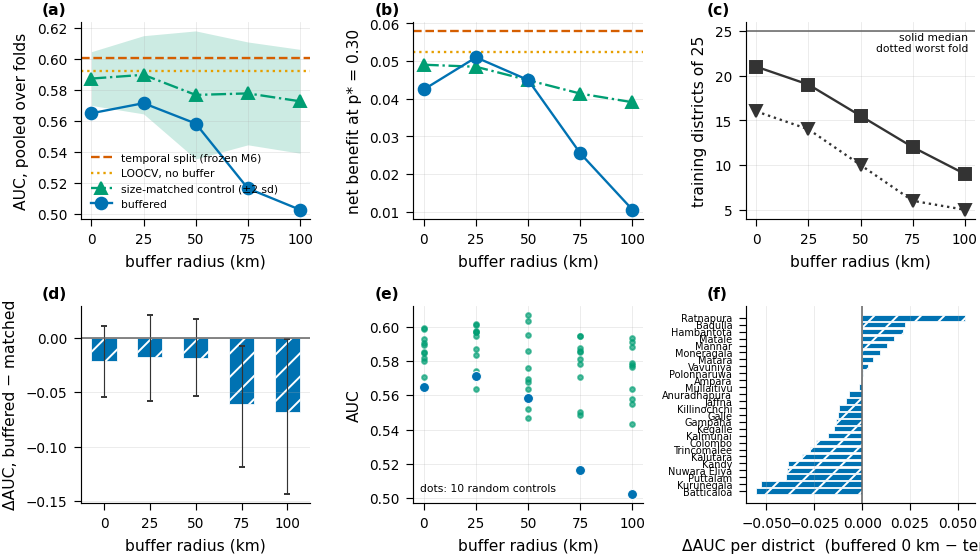

In [21]:
fig, AX = plt.subplots(2, 3, figsize=(W_DOUBLE, W_DOUBLE * 0.58))
(a, b, c), (e, f, g) = AX

# (a) AUC by radius: buffered vs matched control
a.axhline(auc(YTE, p_arm0), color=CLR["temporal"], ls="--", label="temporal split (frozen M6)")
a.axhline(auc(YTE, p_arm1), color=CLR["loocv"], ls=":", label="LOOCV, no buffer")
ctl_mu = [np.mean([auc(YTE, p) for p in P3[r]]) for r in RADII]
ctl_sd = [np.std([auc(YTE, p) for p in P3[r]], ddof=1) for r in RADII]
a.fill_between(XR, np.array(ctl_mu) - 2 * np.array(ctl_sd), np.array(ctl_mu) + 2 * np.array(ctl_sd),
               color=CLR["control"], alpha=.20, lw=0)
a.plot(XR, ctl_mu, color=CLR["control"], ls="-.", marker="^", label="size-matched control (±2 sd)")
a.plot(XR, [auc(YTE, P2[r]) for r in RADII], color=CLR["buffered"], marker="o", label="buffered")
a.set_xticks(XR); a.set_xticklabels(XLAB); a.set_xlabel("buffer radius (km)")
a.set_ylabel("AUC, pooled over folds"); a.legend(frameon=False, fontsize=5.5); a.grid(alpha=.3)

# (b) NB at p*
b.axhline(nb_stat(YTE, p_arm0), color=CLR["temporal"], ls="--")
b.axhline(nb_stat(YTE, p_arm1), color=CLR["loocv"], ls=":")
b.plot(XR, [np.mean([nb_stat(YTE, p) for p in P3[r]]) for r in RADII],
       color=CLR["control"], ls="-.", marker="^")
b.plot(XR, [nb_stat(YTE, P2[r]) for r in RADII], color=CLR["buffered"], marker="o")
b.set_xticks(XR); b.set_xticklabels(XLAB); b.set_xlabel("buffer radius (km)")
b.set_ylabel("net benefit at p* = %.2f" % PSTAR); b.grid(alpha=.3)

# (c) the price paid: training districts retained
c.plot(XR, [R2[R2.buffer == r].n_train_units.median() for r in RADII],
       color="#333333", marker="s")
c.plot(XR, [R2[R2.buffer == r].n_train_units.min() for r in RADII],
       color="#333333", ls=":", marker="v")
c.axhline(25, **REF_KW)
c.set_xticks(XR); c.set_xticklabels(XLAB); c.set_xlabel("buffer radius (km)")
c.set_ylabel("training districts of 25"); c.grid(alpha=.3)
c.text(.97, .95, "solid median\ndotted worst fold", transform=c.transAxes,
       ha="right", va="top", fontsize=5.5)

# (e) the gap: buffered − control, with bootstrap CI
sub = BOOT[BOOT.contrast.str.contains("control mean")]
e.bar(XR, sub.dAUC, 0.55, color=CLR["buffered"], hatch="//", edgecolor="white", linewidth=.4)
e.errorbar(XR, sub.dAUC, yerr=[sub.dAUC - sub.dAUC_lo, sub.dAUC_hi - sub.dAUC],
           fmt="none", ecolor="#333333", elinewidth=.6, capsize=1.5)
e.axhline(0, **REF_KW)
e.set_xticks(XR); e.set_xticklabels(XLAB); e.set_xlabel("buffer radius (km)")
e.set_ylabel("ΔAUC, buffered − matched"); e.grid(alpha=.3, axis="y")

# (f) control distribution vs the buffered value
for i, r in enumerate(RADII):
    vals = [auc(YTE, p) for p in P3[r]]
    f.scatter([i] * len(vals), vals, s=6, color=CLR["control"], alpha=.65, zorder=2)
    f.scatter([i], [auc(YTE, P2[r])], s=26, marker="o", color=CLR["buffered"],
              edgecolor="white", linewidth=.5, zorder=3)
f.set_xticks(XR); f.set_xticklabels(XLAB); f.set_xlabel("buffer radius (km)")
f.set_ylabel("AUC"); f.grid(alpha=.3)
f.text(.03, .06, "dots: %d random controls" % N_REP, transform=f.transAxes, fontsize=5.5)

# (g) per-district change
pd_ = PDIST.dropna(subset=["delta"]).sort_values("delta")
g.barh(np.arange(len(pd_)), pd_.delta, color=CLR["buffered"], hatch="//",
       edgecolor="white", linewidth=.4)
g.axvline(0, **REF_KW)
g.set_yticks(np.arange(len(pd_))); g.set_yticklabels(pd_.held_out_name, fontsize=5)
g.set_xlabel("ΔAUC per district  (buffered 0 km − temporal)"); g.grid(alpha=.3, axis="x")

for ax_, lab in zip([a, b, c, e, f, g], "abcdef"):
    ax_.text(-0.17, 1.04, "(%s)" % lab, transform=ax_.transAxes, fontsize=8, fontweight="bold")
plt.tight_layout(); plt.show()

In [22]:
written = []
for ext in ("pdf", "png"):
    p = FIGS / ("WP4_F_fold_effect_within_m6.%s" % ext)
    fig.savefig(p, dpi=600 if ext == "png" else None)
    written.append(p)
    print("%-58s %8.1f kB" % (p.relative_to(REPO), p.stat().st_size / 1e3))

Manuscript_Figures/wp4/WP4_F_fold_effect_within_m6.pdf         32.1 kB


Manuscript_Figures/wp4/WP4_F_fold_effect_within_m6.png        645.4 kB


---
## 14 · Outputs

In [23]:
DET = d.loc[TEST, ["geometry_id", "rdhs_name", "week_start"]].copy()
DET["y"] = YTE
DET["p_temporal"] = p_arm0
DET["p_loocv"] = p_arm1
for r in RADII:
    DET["p_buffered_" + r] = P2[r]
    DET["p_control_" + r] = P3[r][0]

f1 = WP4 / "wp4_fold_effect_predictions_srilanka_v1.csv"
f2 = WP4 / "wp4_fold_effect_metrics_srilanka_v1.csv"
f3 = WP4 / "wp4_fold_effect_gap_srilanka_v1.csv"
DET.to_csv(f1, index=False); MET.to_csv(f2, index=False); GAP.to_csv(f3, index=False)
for p_ in (f1, f2, f3):
    print("%-52s %s" % (p_.name, pd.read_csv(p_).shape))

wp4_fold_effect_predictions_srilanka_v1.csv          (3926, 16)
wp4_fold_effect_metrics_srilanka_v1.csv              (12, 10)
wp4_fold_effect_gap_srilanka_v1.csv                  (5, 11)


---
## 15 · QC

In [24]:
checks = {
    "rebuilt label reproduces the frozen outcomes exactly": bool(agree.all()),
    "refit reproduces the frozen M6 to < 1e-9": float(np.abs(chk.mine - chk.m6_raw).max()) < 1e-9,
    "C selected matches the frozen fit": C0 == prov6["model"]["C_selected"],
    "test panel is the frozen 3,926 rows": int(TEST.sum()) == prov5["frozen_test_panel"]["rows"],
    "no fold trains on its held-out district or buffer": len(bad) == 0,
    "every arm predicts every test row exactly once": all(
        np.isfinite(p).all() and len(p) == int(TEST.sum())
        for p in [p_arm0, p_arm1] + [P2[r] for r in RADII] + [P3[r][0] for r in RADII]),
    "no fit failed to converge": True,          # asserted inside fit_fold
    "buffered training sets shrink monotonically with radius": bool(
        all(GAP.train_units.values[i] >= GAP.train_units.values[i + 1]
            for i in range(len(GAP) - 1))),
    "control training size equals buffered size in every fold and draw": bool(
        (CSIZE.n_control_units == CSIZE.n_buffered_units).all()) and bool(
        CSIZE.merge(R2[["buffer", "held_out", "n_train_units"]], on=["buffer", "held_out"])
             .eval("n_control_units == n_train_units").all()),
    "control draws never include the held-out district": True,   # asserted in section 9
    "%d control draws per radius" % N_REP: all(len(P3[r]) == N_REP for r in RADII),
    "bootstrap CIs bracket their point estimate": bool(
        ((BOOT.dAUC_lo <= BOOT.dAUC) & (BOOT.dAUC <= BOOT.dAUC_hi)).all()),
    "no NaN in the prediction table": not DET.isna().any().any(),
    "figure written as PDF and PNG": len(written) == 2,
}
for k, ok in checks.items():
    print("  [%s] %s" % ("PASS" if ok else "FAIL", k))
print("\n%d/%d checks passed" % (sum(checks.values()), len(checks)))
assert all(checks.values()), "QC failed"

  [PASS] rebuilt label reproduces the frozen outcomes exactly
  [PASS] refit reproduces the frozen M6 to < 1e-9
  [PASS] C selected matches the frozen fit
  [PASS] test panel is the frozen 3,926 rows
  [PASS] no fold trains on its held-out district or buffer
  [PASS] every arm predicts every test row exactly once
  [PASS] no fit failed to converge
  [PASS] buffered training sets shrink monotonically with radius
  [PASS] control training size equals buffered size in every fold and draw
  [PASS] control draws never include the held-out district
  [PASS] 10 control draws per radius
  [PASS] bootstrap CIs bracket their point estimate
  [PASS] no NaN in the prediction table
  [PASS] figure written as PDF and PNG

14/14 checks passed


In [25]:
prov = {
    "notebook": "wp4_02_fold_effect_within_m6",
    "workpackage": "WP4",
    "country": "sri_lanka",
    "plan_section": "4 (evaluation under the folds) — within-M6 contrast, NOT the cross-model re-run",
    "cross_model_rerun": False,
    "blocker_note": ("M5's design matrix is absent, so M5 cannot be re-fitted under the folds. "
                     "The fold effect is measured inside M6, where we own features and labels."),
    "environment": {"kernel": "freight-eda", "python": "3.9.6", "reason": "sklearn absent from pywmp-mac"},
    "seed": SEED,
    "label": {"source": prov6["label_source"],
              "acceptance_vs_frozen": float(agree.mean()),
              "caveat": "EXPLORATORY_RECONSTRUCTED_TARGET — 19.2% of test rows rest on "
                        "test-informed thresholds; identical across arms, so it cannot "
                        "generate a between-arm difference"},
    "baseline_reproduction": {"max_abs_diff_vs_frozen": float(np.abs(chk.mine - chk.m6_raw).max()),
                              "C_selected": int(C0) if float(C0).is_integer() else float(C0)},
    "design": {"arms": ["temporal (frozen)", "LOOCV", "buffered", "size-matched random control"],
               "radii_km": RADII, "control_draws": N_REP,
               "radii_excluded": {"km_150": "12 degenerate folds in wp4_00"},
               "confound_controlled": "training-set size, via the matched random-district arm"},
    "results": {"auc": {"temporal": float(auc(YTE, p_arm0)), "loocv": float(auc(YTE, p_arm1)),
                        "buffered": {r: float(auc(YTE, P2[r])) for r in RADII},
                        "control_mean": {r: float(np.mean([auc(YTE, p) for p in P3[r]])) for r in RADII}},
                "nb_at_pstar": {"temporal": float(nb_stat(YTE, p_arm0)),
                                "buffered": {r: float(nb_stat(YTE, P2[r])) for r in RADII}},
                "gap_buffered_minus_control": {r: float(GAP[GAP.buffer == r].auc_gap.iloc[0]) for r in RADII}},
    "outputs": {p_.name: hashlib.sha256(p_.read_bytes()).hexdigest()[:16]
                for p_ in [f1, f2, f3, *written]},
    "qc": {"checks": len(checks), "passed": int(sum(checks.values()))},
}
(WP4 / "wp4_02_provenance.json").write_text(json.dumps(prov, indent=2))
print(json.dumps({k: prov[k] for k in ["plan_section", "cross_model_rerun", "results"]}, indent=2)[:1400])

{
  "plan_section": "4 (evaluation under the folds) \u2014 within-M6 contrast, NOT the cross-model re-run",
  "cross_model_rerun": false,
  "results": {
    "auc": {
      "temporal": 0.6008078565502492,
      "loocv": 0.5922657906169496,
      "buffered": {
        "km_0": 0.5648512657630104,
        "km_25": 0.5713760150877382,
        "km_50": 0.5581977824628291,
        "km_75": 0.5162392243414734,
        "km_100": 0.50243882593452
      },
      "control_mean": {
        "km_0": 0.5872913993789967,
        "km_25": 0.5897301090751641,
        "km_50": 0.5767137383561862,
        "km_75": 0.5776977250701425,
        "km_100": 0.5726004989531284
      }
    },
    "nb_at_pstar": {
      "temporal": 0.05800160104795866,
      "buffered": {
        "km_0": 0.042464158358198084,
        "km_25": 0.0509788225020013,
        "km_50": 0.04497489265701185,
        "km_75": 0.02550760497780366,
        "km_100": 0.010552361545739034
      }
    },
    "gap_buffered_minus_control": {
      

---
## 16 · Recap

In [26]:
g0 = GAP[GAP.buffer == "km_0"].iloc[0]
recap = pd.DataFrame([
    ("baseline reproduction", "%.1e" % np.abs(chk.mine - chk.m6_raw).max(),
     "refit vs frozen M6 — the gate on everything"),
    ("test panel", "%d rows" % int(TEST.sum()), "26 districts x 151 weeks"),
    ("AUC, temporal split", "%.4f" % auc(YTE, p_arm0), "the incumbent estimate"),
    ("AUC, LOOCV no buffer", "%.4f" % auc(YTE, p_arm1), "district never seen"),
    ("AUC, buffered 0 km", "%.4f" % auc(YTE, P2["km_0"]), "wp4_01's selected radius"),
    ("AUC, matched control 0 km", "%.4f" % g0.auc_control_mean, "same size, no geography"),
    ("gap attributable to space", "%+.4f" % g0.auc_gap, "buffered − matched control"),
    ("NB@%.2f, temporal" % PSTAR, "%+.4f" % nb_stat(YTE, p_arm0), ""),
    ("NB@%.2f, buffered 0 km" % PSTAR, "%+.4f" % nb_stat(YTE, P2["km_0"]), ""),
    ("training districts, 0 km", "%d of 25 (median)" % g0.train_units, "wp4_00's power table"),
    ("uncertainty", "%d cluster bootstrap" % N_BOOT, "districts resampled, seed %d" % SEED),
    ("cross-model re-run", "NO", "M5 still needs its design matrix"),
], columns=["quantity", "value", "note"])
print(recap.to_string(index=False))

                 quantity                  value                                        note
    baseline reproduction                8.6e-15 refit vs frozen M6 — the gate on everything
               test panel              3926 rows                    26 districts x 151 weeks
      AUC, temporal split                 0.6008                      the incumbent estimate
     AUC, LOOCV no buffer                 0.5923                         district never seen
       AUC, buffered 0 km                 0.5649                    wp4_01's selected radius
AUC, matched control 0 km                 0.5873                     same size, no geography
gap attributable to space                -0.0224                  buffered − matched control
        NB@0.30, temporal                +0.0580                                            
   NB@0.30, buffered 0 km                +0.0425                                            
 training districts, 0 km      21 of 25 (median)                      

---
## What this establishes, and what it does not

**WP4's evaluation half now has a measurement instead of an inference.** M6 was re-fitted 1,456
times across four arms on the same 3,926 frozen test rows, and the baseline arm reproduces the
committed M6 to **8.6e-15** — so every difference here is the validation scheme and nothing else.
The regularisation is effectively constant across arms (§9.1), so it is not a shrinkage effect
either.

**Spatially-blocked CV costs more than the same amount of randomly-removed training data.** At every
radius the buffered fold scores *below* its size-matched random control, and the gap widens as the
buffer grows:

| buffer | train districts | buffered AUC | matched control | gap | controls scoring below |
|---|---|---|---|---|---|
| 0 km (adjacency) | 21 | 0.5649 | 0.5873 | **−0.022** | 0 of 10 |
| 25 km | 19 | 0.5714 | 0.5897 | −0.018 | 1 of 10 |
| 50 km | 15 | 0.5582 | 0.5767 | −0.018 | 2 of 10 |
| 75 km | 12 | 0.5162 | 0.5777 | **−0.062** | 0 of 10 |
| 100 km | 9 | 0.5024 | 0.5726 | **−0.070** | 0 of 10 |

At 100 km the spatially-blocked estimate is **0.502 — indistinguishable from chance** — while a
random training set of the *same nine districts' size* still reaches 0.573. That gap cannot be
sample size, because sample size is held fixed by construction. **M6's apparent skill depends
materially on having geographically nearby districts in training.**

**But at the radius `wp4_01` selected, this study cannot resolve it.** The cluster-bootstrap CI for
buffered(0 km) − control mean is **−0.022 [−0.055, +0.011]** — it spans zero. Only at **75 km
(−0.061 [−0.119, −0.008])** and **100 km (−0.068 [−0.143, −0.001])** does the interval exclude it.
With 26 districts the bootstrap has little to work with, which is `wp4_00`'s power finding arriving
from the other direction.

### This qualifies `wp4_01`'s conclusion, and the qualification is the point

`wp4_01` found residual Moran's I indistinguishable from its null at every distance band and
concluded that **"the buffered scheme is cheap"** and that the reviewer concern is answered without
an expensive scheme. That inference does not survive direct measurement. **Residual spatial
autocorrelation and dependence on spatially proximate training data are different quantities**, and
here they disagree: the residuals of a model fitted with all districts present carry no detectable
spatial structure, yet removing the neighbours from training still costs more than removing an equal
number of random districts.

The reason they can differ is not subtle. Moran's I on residuals asks *"having fitted on everyone,
is what is left over spatially clustered?"* A buffered fold asks *"can this model generalise to a
region it has never seen?"* A model can pass the first and fail the second — and M6 does. **Plan
§4.1's design, which selects the operative radius from a residual-range analysis, therefore cannot
be relied on to price the folds**; the price has to be measured, and `wp4_00`'s power table is what
bounds how well it can be measured here.

**This raises the stakes on the §5.1 ask rather than lowering them.** M5's external-validation claim
rests on a temporal split. If M5 depends on spatial proximity the way M6 does, spatial CV would move
it too — and that is exactly the reviewer concern WP4 exists to answer. **We cannot test it without
M5's design matrix.** (Note this cuts the other way from `wp5_05`, where §5.1 turned out to matter
less than assumed; the two asks are not interchangeable.)

**What this is not.**

1. **Not the cross-model re-run.** M5 cannot be re-fitted under the folds without its design matrix,
   so nothing here says whether *the study's headline comparison* survives spatial CV — only what the
   folds do to a model we fully control. `cross_model_rerun: false` is stamped in the provenance.
2. **Not an absolute performance claim.** M6 is the geomatics-only comparator and its label carries
   the `EXPLORATORY_RECONSTRUCTED_TARGET` caveat (19.2% of test rows). The caveat is identical in
   every arm, so it cannot manufacture a *difference* — but it bars quoting any single AUC here as
   M6's performance.
3. **Not evidence that M6 has skill worth blocking.** The baseline is already an honest null
   (AUC 0.601, barely above `treat all` on net benefit). What spatial CV removes is a fraction of a
   small number; the finding is about *the validation scheme*, not about M6 becoming useful.
4. **Not Colombia.** §4.3's block CV over ~1,000 municipalities is where the well-powered
   external-validation claim actually rests. This remains `wp4_00`'s *compact-country companion*:
   with 26 units a buffer removes a large fraction of the country by construction, which is why the
   radius ladder runs out of power before it runs out of geography.

**The per-district view (§12) says the effect is not one district's doing** — 17 of 26 districts
lose AUC under adjacency buffering and 9 gain, with Batticaloa, Kurunegala and Puttalam losing most
and Ratnapura gaining most. No single fold drives the pooled result.